In [ ]:
# make top level dir available
# import sys
# sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt

from typing import Optional

In [2]:
# custom values in m
EDGE_LENGTH = 9e-3
EDGE_OFFSET = 1e-5

# given paramters in m
OUTER_RADIUS = 0.06
INNER_RADIUS = 0.02
MATERIAL_WIDTH = 0.004
HEIGHT = 0.1

CONNECTOR_ANGLE = 10 * np.pi/180   # in rad
CONNECTOR_1_VOLTAGE = 1                     # in V
CONNECTOR_2_VOLTAGE = -CONNECTOR_1_VOLTAGE  # in V

## Define Points

In [ ]:
# points on the inner circle
position_4 = myfunc.assemble_point(4, INNER_RADIUS, width=0.5*MATERIAL_WIDTH, invert=True)
position_5 = myfunc.assemble_point(5, INNER_RADIUS, width=0.5*MATERIAL_WIDTH)

# points on the outer circle
position_9  = myfunc.assemble_point(9,  OUTER_RADIUS, 7/4*np.pi - CONNECTOR_ANGLE/2)
position_10 = myfunc.assemble_point(10, OUTER_RADIUS, 7/4*np.pi + CONNECTOR_ANGLE/2)
position_11 = myfunc.assemble_point(11, OUTER_RADIUS, 3/4*np.pi - CONNECTOR_ANGLE/2)
position_12 = myfunc.assemble_point(12, OUTER_RADIUS, 3/4*np.pi + CONNECTOR_ANGLE/2)
position_13 = myfunc.assemble_point(13, OUTER_RADIUS, width=-0.5*MATERIAL_WIDTH)
position_17 = myfunc.assemble_point(17, OUTER_RADIUS, width=-0.5*MATERIAL_WIDTH, invert=True)

all_positions = [position_4, position_5, position_9, position_10, position_11, position_12, position_13, position_17]

Index   Angle [rad]           x           y
------------------------------------------
    4             -      0.0020     -0.0199
    5             -      0.0020      0.0199
    9        5.4105      0.0386     -0.0460
   10        5.5851      0.0460     -0.0386
   11        2.2689     -0.0386      0.0460
   12        2.4435     -0.0460      0.0386
   13             -     -0.0020      0.0600
   17             -     -0.0020     -0.0600


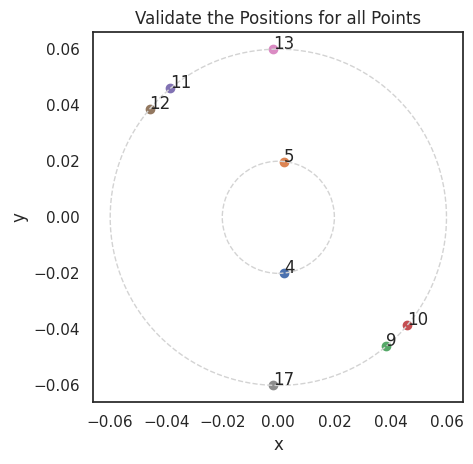

In [5]:
fig, ax = plt.subplots()

print(f"{'Index':>5}  {'Angle [rad]':>12}  {'x':>10}  {'y':>10}")
print("-" * 42)

for position in all_positions:
    index = position["index"]
    angle = position.get("angle")
    x, y = get_xy(position)

    angle_str = f"{angle:.4f}" if angle is not None else "   -"
    print(f"{index:5}  {angle_str:>12}  {x:10.4f}  {y:10.4f}")

    ax.scatter(x, y)
    ax.text(x, y, str(index))  

# scaled circle
outer_circle = plt.Circle((0, 0), OUTER_RADIUS, color='lightgray', fill=False, linestyle='--')  
ax.add_patch(outer_circle)
inner_circle = plt.Circle((0, 0), INNER_RADIUS, color='lightgray', fill=False, linestyle='--')  
ax.add_patch(inner_circle)

ax.set_title("Validate the Positions for all Points")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", "box")

plt.tight_layout()
plt.show()

## Create Mesh

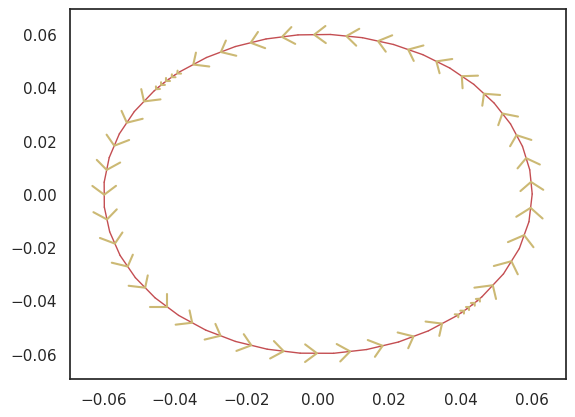

In [6]:
nodes1, elements1 = mt.CircleSegments(middle=(0,0), radius=OUTER_RADIUS, edge_length=EDGE_LENGTH,   a_min=0,                      a_max=position_11["angle"])
nodes2, elements2 = mt.CircleSegments(middle=(0,0), radius=OUTER_RADIUS, edge_length=EDGE_LENGTH/5, a_min=position_11["angle"],   a_max=position_12["angle"])
nodes3, elements3 = mt.CircleSegments(middle=(0,0), radius=OUTER_RADIUS, edge_length=EDGE_LENGTH,   a_min=position_12["angle"],   a_max=position_9["angle"])
nodes4, elements4 = mt.CircleSegments(middle=(0,0), radius=OUTER_RADIUS, edge_length=EDGE_LENGTH/5, a_min=position_9["angle"],    a_max=position_10["angle"])
nodes5, elements5 = mt.CircleSegments(middle=(0,0), radius=OUTER_RADIUS, edge_length=EDGE_LENGTH,   a_min=position_10["angle"],   a_max=np.pi*2)

nodes0, elements0 = mt.AddMultipleSegments( 
    nodes1, 
    nodes2,
    nodes3,
    nodes4,
    nodes5,
)

mt.PlotBoundary(nodes0, elements0, btype="Segments")
plt.show()

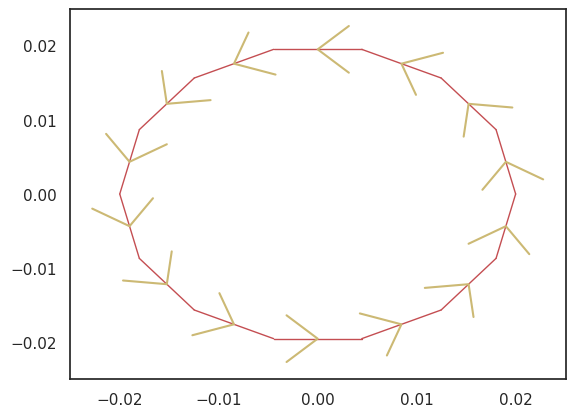

In [7]:
nodes10, elements10 = mt.CircleSegments(middle=(0,0), radius=INNER_RADIUS, edge_length=EDGE_LENGTH)

mt.PlotBoundary(nodes10, elements10, btype="Segments")
plt.show()

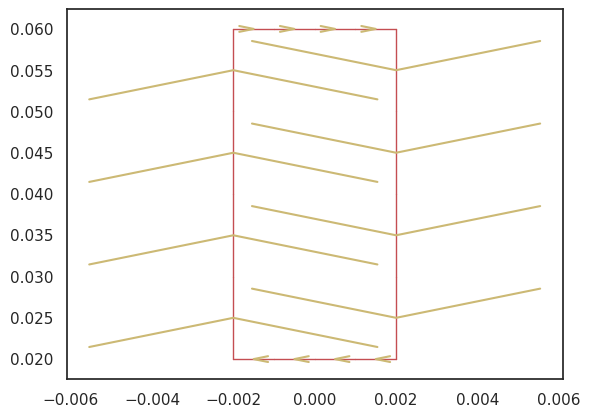

In [8]:
nodes20, elements20 = mt.RectangleSegments(P1=get_xy(position_5), P2=get_xy(position_13), edge_length=EDGE_LENGTH)

mt.PlotBoundary(nodes20, elements20, btype="Segments")
plt.show()

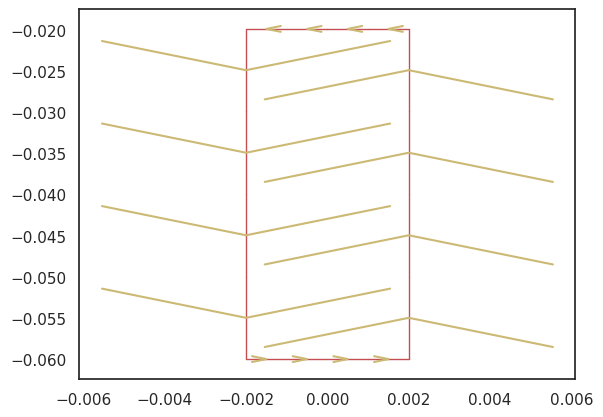

In [9]:
nodes30, elements30 = mt.RectangleSegments(P1=get_xy(position_17), P2=get_xy(position_4), edge_length=EDGE_LENGTH)

mt.PlotBoundary(nodes30, elements30, btype="Segments")
plt.show()

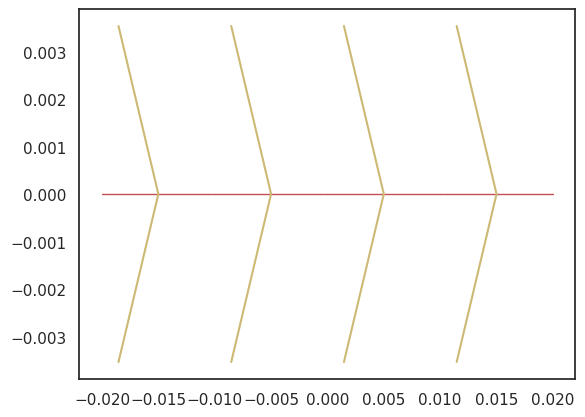

In [10]:
nodes40, elements40 = mt.LineSegments(P1=(-INNER_RADIUS, EDGE_OFFSET), P2=(INNER_RADIUS, EDGE_OFFSET), edge_length=EDGE_LENGTH)

mt.PlotBoundary(nodes40, elements40, btype="Segments")
plt.show()

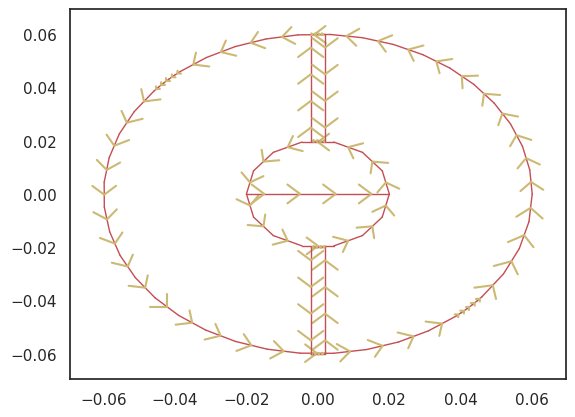

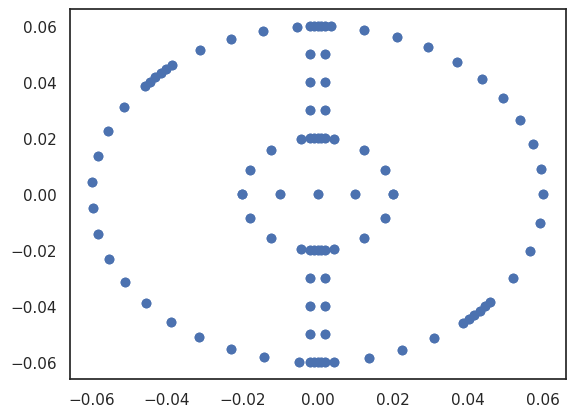

In [11]:
nodes, elements, indicies = mt.AddMultipleCurves(nodes0, elements0, nodes10, elements10, nodes20, elements20, nodes30, elements30, nodes40, elements40)

mt.PlotBoundary(nodes, elements, btype="Segments")
plt.show()
mt.PlotBoundary(nodes, elements, btype="Nodes")
plt.show()

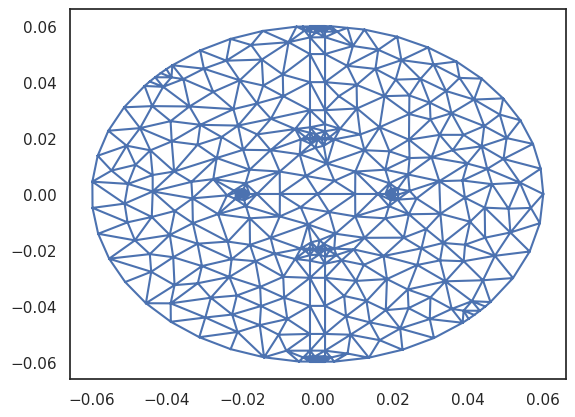

In [12]:
knots,triangles,boundary_edge,boundary_indices,boundary_elements,outer_curve,inner_curve = mt.DoTriMesh(nodes, elements, edge_length=EDGE_LENGTH)

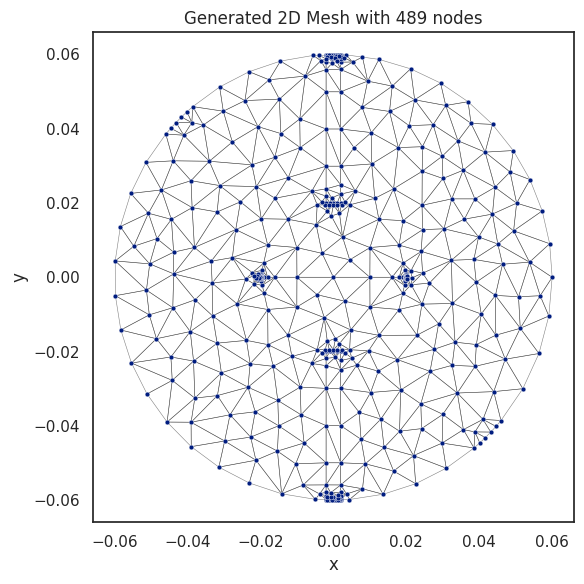

In [13]:
myfunc.plot_knots_elements(knots, triangles)

## Get Boundaries

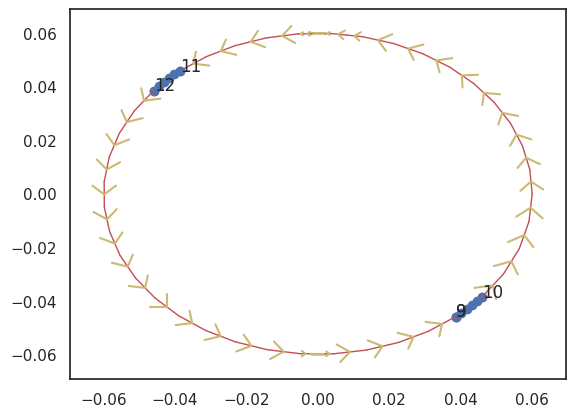

In [14]:
BOUNDARY_POSITIONS = []
for position in [position_9, position_10, position_11, position_12, position_9]:
    index = position["index"]
    x, y = position["x"], position["y"]

    BOUNDARY_POSITIONS += [[x, y]]

    plt.scatter(x,y)
    plt.text(x,y,index)
    
# plt.show()

PATH_TYPES = ["Nodes", "Segments", "Nodes", "Segments"]
bseg = mt.RetrieveSegments(knots,boundary_edge,boundary_indices, BOUNDARY_POSITIONS, PATH_TYPES)
mt.PlotBoundary(knots, bseg[0], "Nodes")
mt.PlotBoundary(knots, bseg[1], "Segments")
mt.PlotBoundary(knots, bseg[2], "Nodes")
mt.PlotBoundary(knots, bseg[3], "Segments")